# BIOT Encoder t-SNE Visualization

This notebook loads a BIOT pretrained checkpoint from `results/biot`, extracts encoder embeddings, and plots two t-SNE views in a single 1x2 layout:

1. Colored by class label (`1=ADHD`, `0=Control`)
2. Colored by subject group ID (all epochs from the same subject share color)

Note: BIOT can consume varying input channel counts. This notebook keeps the original EEG channels and only expands the encoder's channel-token table when the dataset has more channels than the checkpoint.

In [9]:
from pathlib import Path
import sys

ROOT = Path.cwd()
PROJECT_ROOT = ROOT if (ROOT / "pyproject.toml").exists() else ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import torch
import matplotlib.pyplot as plt
import pickle
from sklearn.manifold import TSNE
from models.biot import BIOTEncoder, BIOTClassifier

DATASET_CANDIDATES = [
    PROJECT_ROOT / "data/ADHD_Control_IEEE/processed/eeg_dataset.pkl",
    PROJECT_ROOT / "data/processed/eeg_dataset.pkl",
]
DATA_DIR = next((p for p in DATASET_CANDIDATES if p.exists()), DATASET_CANDIDATES[0])

PRETRAINED_MODEL = PROJECT_ROOT / "results/biot/EEG-six-datasets-18-channels.ckpt"

# Load Data

In [10]:
with open(DATA_DIR, "rb") as file:
        data = pickle.load(file)

epochs = data['epochs']
labels = data['labels']
groups = data['groups']
subject_map = data.get('subject_map', {})


print('epochs shape:', epochs.shape)
print('labels shape:', labels.shape, 'unique:', np.unique(labels))
print('groups shape:', groups.shape, 'n_subjects:', len(np.unique(groups)))
print('subject_map size:', len(subject_map))

Using legacy in-memory dataset: /var/home/automatica/Documents/GitHub/MIL-Project/data/ADHD_Control_IEEE/processed/eeg_dataset.pkl
dataset samples: 16749
batch size: 32
steps per epoch: 524
subject_map size: 121


In [11]:
encoder = BIOTEncoder(n_channels=19)
for param_tensor in encoder.state_dict():
    print(param_tensor, "\t", encoder.state_dict()[param_tensor].size())

index 	 torch.Size([19])
patch_embedding.projection.weight 	 torch.Size([256, 101])
patch_embedding.projection.bias 	 torch.Size([256])
transformer.layers.layers.0.0.fn.to_q.weight 	 torch.Size([256, 256])
transformer.layers.layers.0.0.fn.to_k.weight 	 torch.Size([256, 256])
transformer.layers.layers.0.0.fn.to_v.weight 	 torch.Size([256, 256])
transformer.layers.layers.0.0.fn.to_out.weight 	 torch.Size([256, 256])
transformer.layers.layers.0.0.fn.to_out.bias 	 torch.Size([256])
transformer.layers.layers.0.0.norm.weight 	 torch.Size([256])
transformer.layers.layers.0.0.norm.bias 	 torch.Size([256])
transformer.layers.layers.0.1.fn.fn.w1.weight 	 torch.Size([1024, 256])
transformer.layers.layers.0.1.fn.fn.w1.bias 	 torch.Size([1024])
transformer.layers.layers.0.1.fn.fn.w2.weight 	 torch.Size([256, 1024])
transformer.layers.layers.0.1.fn.fn.w2.bias 	 torch.Size([256])
transformer.layers.layers.0.1.norm.weight 	 torch.Size([256])
transformer.layers.layers.0.1.norm.bias 	 torch.Size([256])


In [12]:
checkpoint = torch.load(PRETRAINED_MODEL)
for key in checkpoint.keys():
    print(key)

index
patch_embedding.projection.weight
patch_embedding.projection.bias
transformer.layers.layers.0.0.fn.to_q.weight
transformer.layers.layers.0.0.fn.to_k.weight
transformer.layers.layers.0.0.fn.to_v.weight
transformer.layers.layers.0.0.fn.to_out.weight
transformer.layers.layers.0.0.fn.to_out.bias
transformer.layers.layers.0.0.norm.weight
transformer.layers.layers.0.0.norm.bias
transformer.layers.layers.0.1.fn.fn.w1.weight
transformer.layers.layers.0.1.fn.fn.w1.bias
transformer.layers.layers.0.1.fn.fn.w2.weight
transformer.layers.layers.0.1.fn.fn.w2.bias
transformer.layers.layers.0.1.norm.weight
transformer.layers.layers.0.1.norm.bias
transformer.layers.layers.1.0.fn.to_q.weight
transformer.layers.layers.1.0.fn.to_k.weight
transformer.layers.layers.1.0.fn.to_v.weight
transformer.layers.layers.1.0.fn.to_out.weight
transformer.layers.layers.1.0.fn.to_out.bias
transformer.layers.layers.1.0.norm.weight
transformer.layers.layers.1.0.norm.bias
transformer.layers.layers.1.1.fn.fn.w1.weight
tr

In [13]:
checkpoint.pop("index", None)

# Align channel token table to current encoder channel count.
target_channels = encoder.channel_tokens.weight.shape[0]
token_key = "channel_tokens.weight"
if token_key in checkpoint:
    token_weight = checkpoint[token_key]
    pretrained_channels, emb_size = token_weight.shape
    if pretrained_channels < target_channels:
        expanded = torch.empty(target_channels, emb_size, dtype=token_weight.dtype)
        expanded[:pretrained_channels] = token_weight
        torch.nn.init.normal_(expanded[pretrained_channels:])
        checkpoint[token_key] = expanded
    elif pretrained_channels > target_channels:
        checkpoint[token_key] = token_weight[:target_channels]

missing, unexpected = encoder.load_state_dict(checkpoint, strict=False)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
if missing:
    print("Sample missing:", missing[:8])
if unexpected:
    print("Sample unexpected:", unexpected[:8])

Missing keys: 1
Unexpected keys: 0
Sample missing: ['index']


In [14]:
embeddings = encoder(torch.from_numpy(epochs).float())

embeddings shape: (16749, 256)
labels shape: (16749,) unique: [0 1]
groups shape: (16749,) n_subjects: 121


In [15]:
n_samples = embeddings.shape[0]
perplexity = min(30, max(5, n_samples // 10))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate='auto',
    init='pca',
    random_state=42,
)
z = tsne.fit_transform(embeddings.detach().numpy())
print('t-SNE done. shape:', z.shape, 'perplexity:', perplexity)

t-SNE done. shape: (16749, 2) perplexity: 30


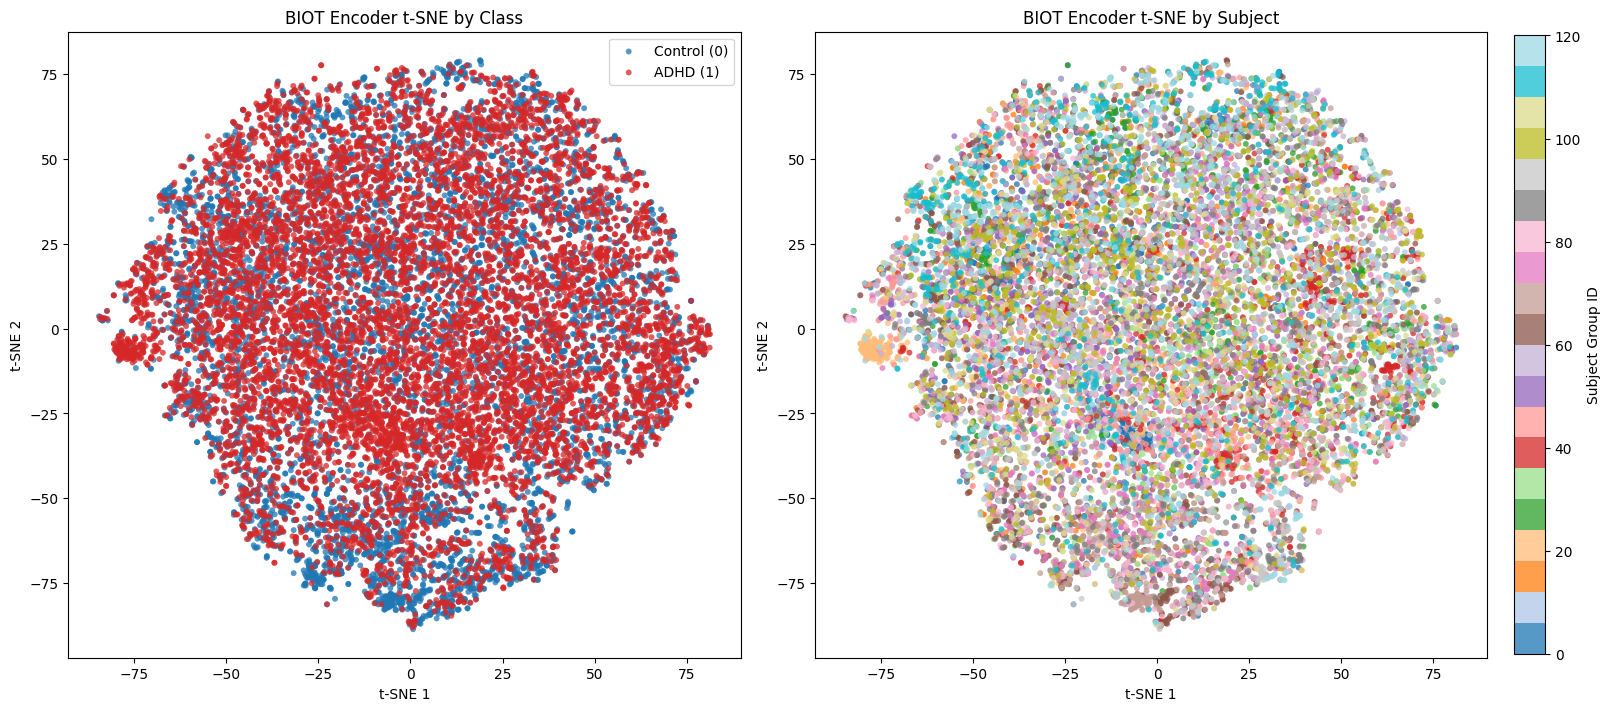

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

# Left: class-colored plot (1=ADHD, 0=Control)
class_colors = {0: '#1f77b4', 1: '#d62728'}
class_names = {0: 'Control (0)', 1: 'ADHD (1)'}
for cls in sorted(np.unique(labels).tolist()):
    mask = labels == cls
    axes[0].scatter(
        z[mask, 0],
        z[mask, 1],
        s=18,
        alpha=0.75,
        c=class_colors.get(int(cls), '#7f7f7f'),
        label=class_names.get(int(cls), f'Class {int(cls)}'),
        edgecolors='none',
    )
axes[0].set_title('BIOT Encoder t-SNE by Class')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(loc='best')

# Right: subject-colored plot (same subject -> same color)
subjects = groups.astype(int)
sc = axes[1].scatter(
    z[:, 0],
    z[:, 1],
    c=subjects,
    cmap='tab20',
    s=18,
    alpha=0.75,
    edgecolors='none',
)
axes[1].set_title('BIOT Encoder t-SNE by Subject')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
cbar = plt.colorbar(sc, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Subject Group ID')

plt.show()